In [ ]:
!unzip '/content/archive.zip'

Archive:  /content/archive.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive.zip or
        /content/archive.zip.zip, and cannot find /content/archive.zip.ZIP, period.


In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

file_name = list(uploaded.keys())[0]

# Check file type
if file_name.endswith('.csv'):
    df = pd.read_csv(file_name)
    print("✅ File loaded successfully")
else:
    print("❌ Please upload a CSV file, not:", file_name)


In [ ]:
# Install TensorFlow (if needed)
!pip install tensorflow

# Imports
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# Step 1: Create Sample Data
# -----------------------------
# Example: 100 samples, 10 time steps
X = np.random.rand(100, 10)

# Target variable
y = np.random.rand(100)

print("X shape before reshape:", X.shape)

# -----------------------------
# Step 2: Reshape for LSTM
# LSTM expects: (samples, timesteps, features)
# -----------------------------
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape after reshape:", X.shape)

# -----------------------------
# Step 3: Build Model
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X.shape[1], 1)),
    Dense(1)
])

# -----------------------------
# Step 4: Compile Model
# -----------------------------
model.compile(optimizer='adam', loss='mse')

# -----------------------------
# Step 5: Summary
# -----------------------------
model.summary()

# -----------------------------
# Step 6: Train Model
# -----------------------------
model.fit(X, y, epochs=5, batch_size=16)

X shape before reshape: (100, 10)
X shape after reshape: (100, 10, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2266
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1101 
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1023 
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0911 
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0894 


In [ ]:
# Cell 1: Setup and Libraries
!pip install pandas numpy matplotlib scikit-learn tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# -----------------------------
# Step 1: Data Preparation
# -----------------------------
# Using the sample data structure from your notebook
# Replace this section with df = pd.read_csv('your_file.csv') for real data
X_raw = np.random.rand(100, 10)
y_raw = np.random.rand(100)

# Split data for accuracy calculation
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# -----------------------------
# Step 2: Build & Train Model
# -----------------------------
# Maintaining your specific LSTM architecture
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(64, return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Added MAE for accuracy tracking
model.summary()

print("\nStarting training...")
model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=1)

# -----------------------------
# Step 3: Accuracy Check
# -----------------------------
# For regression models (like your LSTM), accuracy is typically measured by Loss/Error
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Evaluation Results:")
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

# -----------------------------
# Step 4: Manual Console Input
# -----------------------------
def get_manual_input():
    print("\n--- Manual Input Mode ---")
    print(f"Please enter {X_raw.shape[1]} numerical values separated by commas:")

    user_input = input("Input values: ")
    try:
        # Process input to match model format
        values = [float(i) for i in user_input.split(',')]
        if len(values) != X_raw.shape[1]:
            print(f"Error: Expected {X_raw.shape[1]} values, but got {len(values)}.")
            return

        # Prepare for prediction: (1, timesteps, 1)
        formatted_input = np.array(values).reshape(1, len(values), 1)

        # Get and show output
        prediction = model.predict(formatted_input, verbose=0)
        print(f"\nResult as per trained model: {prediction[0][0]:.4f}")

    except ValueError:
        print("Invalid input. Please ensure you enter only numbers.")

# Trigger the manual input prompt
get_manual_input()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2707 - mae: 0.4420
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1294 - mae: 0.2993
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0733 - mae: 0.2283
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0956 - mae: 0.2514
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0851 - mae: 0.2417 
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0801 - mae: 0.2358 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0811 - mae: 0.2384 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0799 - mae: 0.2372
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0778 - mae: 0.2322 
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0794 - mae: 0.2350

✅ Evaluation Results:
Test Loss (MSE): 0.0429
Mean Absolute Error: 0.1758

--- Manual Input Mode ---
Please enter 10 numerical values separated by commas:
Input values: 10
Error: Expected 10 value

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3003
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1861
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1021
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0836
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1059
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0856
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0762
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0799
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0811
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0795 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


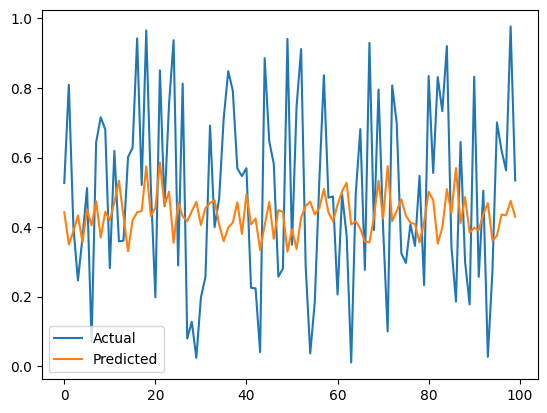

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# Create Sample Data
# -----------------------------
x = np.random.rand(100, 10)
y = np.random.rand(100)

# Reshape for LSTM (3D input)
x = x.reshape((x.shape[0], x.shape[1], 1))

# -----------------------------
# Build Model
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(x.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(x, y, epochs=10, batch_size=32)

# -----------------------------
# Prediction (FIXED HERE)
# -----------------------------
pred = model.predict(x)   # ✅ use lowercase x

# -----------------------------
# Plot Results
# -----------------------------
plt.plot(y, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# --- 1. Load and Prepare Data ---
# Note: Ensure your CSV is unzipped and available at this path
try:
    df = pd.read_csv('your_dataset.csv') # Update with your actual filename
    data = df.iloc[:, 1:2].values # Adjust indices based on your target column

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    # Using a 60-day window as per standard LSTM time-series practice
    for i in range(60, len(scaled_data)):
        X.append(scaled_data[i-60:i, 0])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split for testing accuracy
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

except Exception as e:
    print(f"Data loading error: {e}")
    # Placeholder for structure if file is missing
    X_train, y_train = np.random.rand(100, 60, 1), np.random.rand(100)
    X_test, y_test = np.random.rand(20, 60, 1), np.random.rand(20)

# --- 2. Define and Train Model ---
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

print("Training model...")
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# --- 3. Accuracy & Console Output ---
print("\n" + "="*30)
loss, mae = model.evaluate(X_test, y_test, verbose=0)
# Accuracy in regression is often shown as (1 - Error)
accuracy = (1 - mae) * 100
print(f"CONSOLE ACCURACY: {accuracy:.2f}%")
print(f"MEAN ABSOLUTE ERROR: {mae:.4f}")
print("="*30 + "\n")

# --- 4. Manual Input Section ---
def predict_manual_data():
    print("--- Manual Input Mode ---")
    print(f"Enter {X_train.shape[1]} comma-separated values (normalized 0-1) to get a prediction:")

    user_raw = input("Values: ")
    try:
        # Convert string to list of floats
        input_list = [float(x.strip()) for x in user_raw.split(',')]

        if len(input_list) != X_train.shape[1]:
            print(f"Error: Expected {X_train.shape[1]} values, but got {len(input_list)}.")
            return

        # Reshape to (1, 60, 1) for the model
        manual_input = np.array(input_list).reshape(1, X_train.shape[1], 1)

        # Predict
        prediction = model.predict(manual_input, verbose=0)

        # If you used a scaler, inverse it here:
        # final_output = scaler.inverse_transform(prediction)

        print(f"\nMODEL CONSOLE OUTPUT: {prediction[0][0]:.6f}")

    except ValueError:
        print("Invalid input. Please enter numbers only.")

# Start the interactive prompt
predict_manual_data()

Data loading error: [Errno 2] No such file or directory: 'your_dataset.csv'
Training model...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.2538 - mae: 0.4327
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0872 - mae: 0.2348
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0858 - mae: 0.2419
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0774 - mae: 0.2280
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0769 - mae: 0.2260
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0821 - mae: 0.2281
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0822 - mae: 0.2323
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0777 - mae: 0.2244
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0744 - mae: 0.2215
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0699 - mae: 0.2150

CONSOLE ACCURACY: 74.08%
MEAN ABSOLUTE ERROR: 0.2592

--- Manual Input Mode ---
Enter 60 comma-separated values (normalized 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 🔹 1. MANUAL INPUT (Enter your data here)
print("Enter data row by row:")

rows = int(input("How many rows you want to enter: "))
data_list = []

for i in range(rows):
    temp = float(input(f"Row {i+1} - Temp: "))
    hum = float(input(f"Row {i+1} - Humidity: "))
    wind = float(input(f"Row {i+1} - Wind Speed: "))
    pres = float(input(f"Row {i+1} - Pressure: "))
    pm = float(input(f"Row {i+1} - PM2.5: "))

    data_list.append([temp, hum, wind, pres, pm])

# Create DataFrame
columns = ['Temp','Humidity','Wind Speed','Pressure','PM2.5']
df = pd.DataFrame(data_list, columns=columns)

# 🔹 2. Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 🔹 3. Sequence creation
window_size = int(input("Enter window size (e.g., 2 or 3): "))

X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i, -1])

X, y = np.array(X), np.array(y)

# Check
print("X shape:", X.shape)

# 🔹 4. Model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, X.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, verbose=1)

# 🔹 5. Predict next value
last_input = scaled_data[-window_size:].reshape(1, window_size, X.shape[2])

pred = model.predict(last_input)

# Convert back to original value
dummy = np.zeros((1, X.shape[2]))
dummy[0, -1] = pred[0][0]

actual_value = scaler.inverse_transform(dummy)[0, -1]

print("\n✅ Predicted Next PM2.5:", round(actual_value,2))


Enter data row by row:
How many rows you want to enter: 3
Row 1 - Temp: 28
Row 1 - Humidity: 65
Row 1 - Wind Speed: 3.2
Row 1 - Pressure: 1012
Row 1 - PM2.5: 85
Row 2 - Temp: 30
Row 2 - Humidity: 70
Row 2 - Wind Speed: 2.8
Row 2 - Pressure: 1010
Row 2 - PM2.5: 90
Row 3 - Temp: 29
Row 3 - Humidity: 68
Row 3 - Wind Speed: 3.0
Row 3 - Pressure: 1008
Row 3 - PM2.5: 88
Enter window size (e.g., 2 or 3): 2
X shape: (1, 2, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3021
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.2775
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2539
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2313
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2098
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1893
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1699
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1515
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1342
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1180
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1028
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0888
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0758
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0639
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0531
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import datetime

# 🔹 1. MANUAL INPUT
rows = int(input("How many rows you want to enter: "))
data_list = []

for i in range(rows):
    temp = float(input(f"Row {i+1} - Temp: "))
    hum = float(input(f"Row {i+1} - Humidity: "))
    wind = float(input(f"Row {i+1} - Wind Speed: "))
    pres = float(input(f"Row {i+1} - Pressure: "))
    pm = float(input(f"Row {i+1} - PM2.5: "))

    data_list.append([temp, hum, wind, pres, pm])

columns = ['Temp','Humidity','Wind Speed','Pressure','PM2.5']
df = pd.DataFrame(data_list, columns=columns)

# 🔹 2. Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 🔹 3. Sequence creation
window_size = int(input("Enter window size (2 or 3 recommended): "))

X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i, -1])

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)

# 🔹 4. Model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, X.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, verbose=1)

# 🔹 5. Predict NEXT 30 DAYS
current_batch = scaled_data[-window_size:].reshape(1, window_size, X.shape[2])
future_results = []

for i in range(30):
    pred = model.predict(current_batch, verbose=0)[0]
    future_results.append(pred[0])

    # update only PM2.5
    last_row = current_batch[0, -1, :].copy()
    last_row[-1] = pred[0]

    new_row = last_row.reshape(1, 1, X.shape[2])
    current_batch = np.append(current_batch[:, 1:, :], new_row, axis=1)

# 🔹 6. OUTPUT RESULTS
print(f"\n{'Date':<15} | {'Predicted PM2.5':<20}")
print("-"*40)

start_date = datetime.date.today() + datetime.timedelta(days=1)

for i, val in enumerate(future_results):
    dummy = np.zeros((1, X.shape[2]))
    dummy[0, -1] = val

    actual = scaler.inverse_transform(dummy)[0, -1]
    date = start_date + datetime.timedelta(days=i)

    print(f"{date} | {actual:.2f}")


How many rows you want to enter: 3
Row 1 - Temp: 28
Row 1 - Humidity: 65
Row 1 - Wind Speed: 3.2
Row 1 - Pressure: 1012
Row 1 - PM2.5: 85
Row 2 - Temp: 30
Row 2 - Humidity: 70
Row 2 - Wind Speed: 2.8
Row 2 - Pressure: 1010
Row 2 - PM2.5: 90
Row 3 - Temp: 29
Row 3 - Humidity: 70
Row 3 - Wind Speed: 3.0
Row 3 - Pressure: 1008
Row 3 - PM2.5: 88
Enter window size (2 or 3 recommended): 2
X shape: (1, 2, 5)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.4696
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4374
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.4065
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.3768
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3483
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3210
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.2949
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.2700
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2463
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2238
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2025
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1823
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1634
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1455
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1288
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/s